# Road Damage Multiclass Classification: Model Evaluation

This notebook evaluates the performance of three deep learning models trained for road damage classification.

Models evaluated:

- ResNet18
- MobileNetV3-Small
- EfficientNet-B0

The evaluation pipeline consists of:

1. Model inference
2. Prediction analysis
3. Performance metrics
4. Confusion matrix analysis
5. Model comparison
6. Final model selection

## Imports

In [1]:
!git clone https://github.com/gracyy-rm/road-damage-multiclass-classification

Cloning into 'road-damage-multiclass-classification'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 69 (delta 34), reused 56 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 8.42 MiB | 26.68 MiB/s, done.
Resolving deltas: 100% (34/34), done.


In [3]:
%cd /kaggle/working/road-damage-multiclass-classification

/kaggle/working/road-damage-multiclass-classification


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cvcore as cr

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from src.inference import RoadDamageInference


## Define dataset and model paaths

In [5]:
TEST_CSV = "/kaggle/input/datasets/gracyyadav79/test-data/test.csv"
RESNET_MODEL = "/kaggle/input/datasets/gracyyadav79/model-experiments/final_experiments/resnet18_lr0.001_bs32_20260818_103937/best_model_acc_90.7.pth"
MOBILENET_MODEL = "/kaggle/input/datasets/gracyyadav79/model-experiments/final_experiments/mobilenet_v3_small_lr0.001_bs32_20260818_111047/best_model_acc_90.7.pth"
EFFICIENTNET_MODEL = "/kaggle/input/datasets/gracyyadav79/model-experiments/final_experiments/efficientnet_b0_lr0.001_bs32_20260818_101235/best_model_acc_93.2.pth"

## ResNet18 Inference

In [6]:
resnet = RoadDamageInference(model_path=RESNET_MODEL)
resnet_df = resnet.predict_csv_batch(TEST_CSV)
resnet_df.head()


--- Checkpoint Information ---
Model: resnet18
Image Size: 224
Classes: 5
Checkpoint: /kaggle/input/datasets/gracyyadav79/model-experiments/final_experiments/resnet18_lr0.001_bs32_20260818_103937/best_model_acc_90.7.pth
--------------------------------

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 86.5MB/s]
Inference: 100%|██████████| 30/30 [01:11<00:00,  2.40s/it]


,image_path,image_name,true_label,true_class,pred_label,pred_class_name,confidence_score
0,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0253.jpg,0,Major Damage,0,Major Damage,70.40
1,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0296.jpg,0,Major Damage,0,Major Damage,98.95
2,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0036.jpg,0,Major Damage,0,Major Damage,97.21
3,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0076.jpg,0,Major Damage,0,Major Damage,99.99
4,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0308.jpg,0,Major Damage,0,Major Damage,100.00


### ResNet18 Prediction Distribution

In [7]:
resnet_df["pred_class_name"].value_counts()

pred_class_name
Major Damage     298
Minor Damage     232
Normal Road      200
Speed Breaker    145
Manhole           82
Name: count, dtype: int64

In [8]:
resnet_df["true_class"].value_counts()

true_class
Major Damage     310
Minor Damage     221
Normal Road      200
Speed Breaker    142
Manhole           84
Name: count, dtype: int64

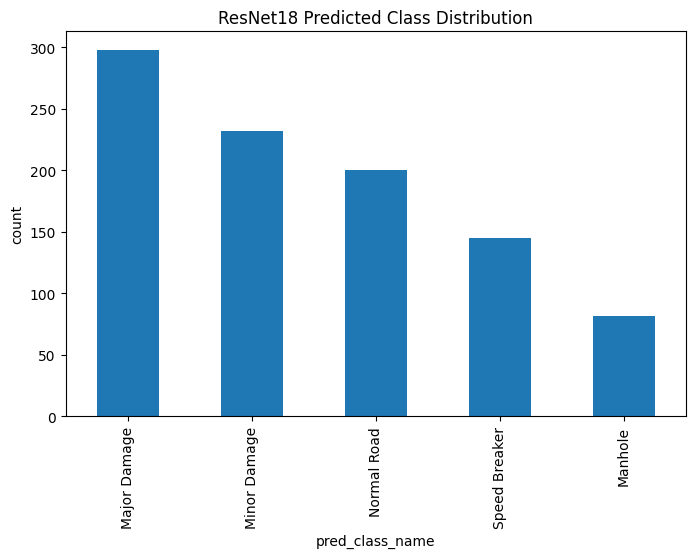

In [9]:
resnet_df['pred_class_name'].value_counts().plot(kind='bar',figsize=(8,5))
plt.ylabel("count")
plt.title("ResNet18 Predicted Class Distribution")
plt.show()

### ResNet18 Confidence Score Distribution

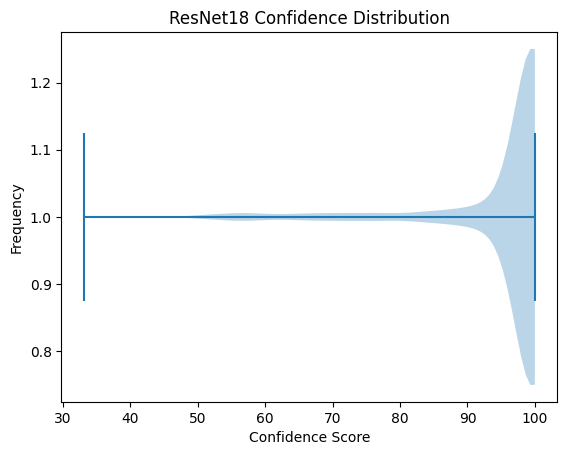

In [10]:
resent_conf_df=resnet_df["confidence_score"]
plt.violinplot(vert=False,dataset=resent_conf_df)
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.title("ResNet18 Confidence Distribution")
plt.show()

### Highest Confidence Predictions

In [11]:
resnet_df.sort_values("confidence_score",ascending=False).head(10)

,image_path,image_name,true_label,true_class,pred_label,pred_class_name,confidence_score
956,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0024.jpg,4,Speed Breaker,4,Speed Breaker,100.0
955,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0021.jpg,4,Speed Breaker,4,Speed Breaker,100.0
942,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0119.jpg,4,Speed Breaker,4,Speed Breaker,100.0
941,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0084.jpg,4,Speed Breaker,4,Speed Breaker,100.0
940,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0117.jpg,4,Speed Breaker,4,Speed Breaker,100.0
27,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0168.jpg,0,Major Damage,0,Major Damage,100.0
25,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0177.jpg,0,Major Damage,0,Major Damage,100.0
24,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0176.jpg,0,Major Damage,0,Major Damage,100.0
4,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0308.jpg,0,Major Damage,0,Major Damage,100.0
6,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0254.jpg,0,Major Damage,0,Major Damage,100.0


### Lowest Confidence Predictions

In [12]:
resnet_df.sort_values("confidence_score").head(10)

,image_path,image_name,true_label,true_class,pred_label,pred_class_name,confidence_score
336,/kaggle/input/datasets/gracyyadav79/road-damag...,test_manhole_0014.jpg,1,Manhole,1,Manhole,33.10
178,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0104.jpg,0,Major Damage,4,Speed Breaker,39.38
395,/kaggle/input/datasets/gracyyadav79/road-damag...,test_minor_damage_0073.jpg,2,Minor Damage,4,Speed Breaker,49.39
747,/kaggle/input/datasets/gracyyadav79/road-damag...,test_normal_road_0176.jpg,3,Normal Road,2,Minor Damage,50.48
458,/kaggle/input/datasets/gracyyadav79/road-damag...,test_minor_damage_0016.jpg,2,Minor Damage,0,Major Damage,50.67
401,/kaggle/input/datasets/gracyyadav79/road-damag...,test_minor_damage_0096.jpg,2,Minor Damage,3,Normal Road,51.02
228,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0271.jpg,0,Major Damage,0,Major Damage,51.25
601,/kaggle/input/datasets/gracyyadav79/road-damag...,test_minor_damage_0047.jpg,2,Minor Damage,2,Minor Damage,52.45
486,/kaggle/input/datasets/gracyyadav79/road-damag...,test_minor_damage_0018.jpg,2,Minor Damage,2,Minor Damage,52.96
127,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0041.jpg,0,Major Damage,2,Minor Damage,53.46


## MobileNetV3 Inference

In [13]:
mobilenet = RoadDamageInference(model_path=MOBILENET_MODEL)
mobilenet_df=mobilenet.predict_csv_batch(TEST_CSV)
mobilenet_df.head()


--- Checkpoint Information ---
Model: mobilenet_v3_small
Image Size: 224
Classes: 5
Checkpoint: /kaggle/input/datasets/gracyyadav79/model-experiments/final_experiments/mobilenet_v3_small_lr0.001_bs32_20260818_111047/best_model_acc_90.7.pth
--------------------------------

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 115MB/s]
Inference: 100%|██████████| 30/30 [00:15<00:00,  1.92it/s]


,image_path,image_name,true_label,true_class,pred_label,pred_class_name,confidence_score
0,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0253.jpg,0,Major Damage,0,Major Damage,98.90
1,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0296.jpg,0,Major Damage,0,Major Damage,100.00
2,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0036.jpg,0,Major Damage,0,Major Damage,98.67
3,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0076.jpg,0,Major Damage,0,Major Damage,99.96
4,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0308.jpg,0,Major Damage,0,Major Damage,100.00


### MobileNetV3 Prediction Distribution

In [14]:
mobilenet_df["pred_class_name"].value_counts()

pred_class_name
Major Damage     311
Minor Damage     220
Normal Road      208
Speed Breaker    137
Manhole           81
Name: count, dtype: int64

In [15]:
mobilenet_df["true_class"].value_counts()

true_class
Major Damage     310
Minor Damage     221
Normal Road      200
Speed Breaker    142
Manhole           84
Name: count, dtype: int64

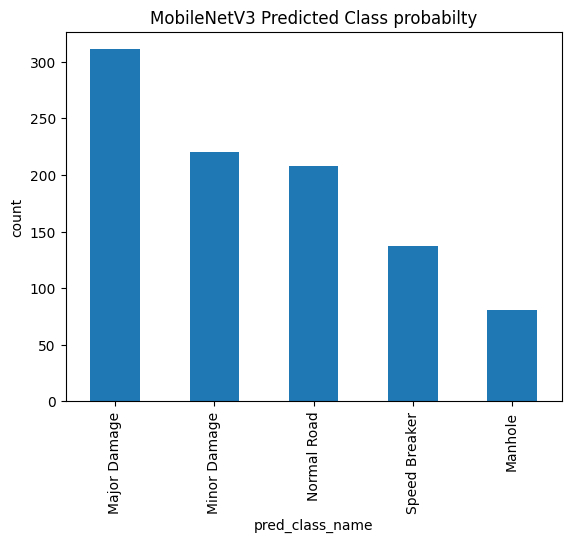

In [16]:
mobilenet_df["pred_class_name"].value_counts().plot(kind="bar")
plt.ylabel("count")
plt.title("MobileNetV3 Predicted Class probabilty")
plt.show()

### MobileNet Confidence Score Distribution

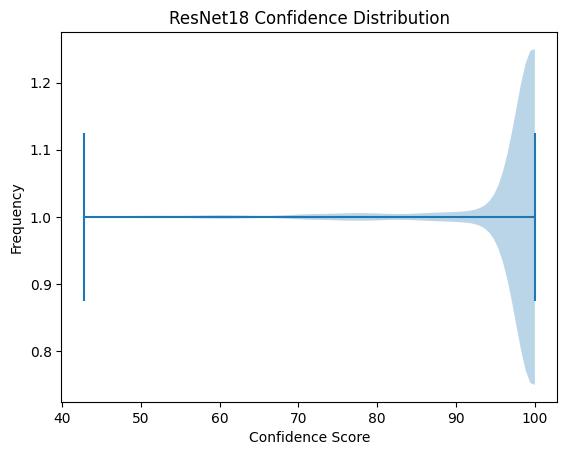

In [32]:
mobilenet_conf_df=mobilenet_df["confidence_score"]
plt.violinplot(vert=False,dataset=mobilenet_conf_df)
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.title("ResNet18 Confidence Distribution")
plt.show()

### Highest Confidence Predictions

In [33]:
mobilenet_df.sort_values("confidence_score",ascending=False).head(10)

,image_path,image_name,true_label,true_class,pred_label,pred_class_name,confidence_score
950,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0092.jpg,4,Speed Breaker,4,Speed Breaker,100.0
954,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0094.jpg,4,Speed Breaker,4,Speed Breaker,100.0
13,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0024.jpg,0,Major Damage,0,Major Damage,100.0
956,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0024.jpg,4,Speed Breaker,4,Speed Breaker,100.0
14,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0189.jpg,0,Major Damage,0,Major Damage,100.0
1,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0296.jpg,0,Major Damage,0,Major Damage,100.0
955,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0021.jpg,4,Speed Breaker,4,Speed Breaker,100.0
15,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0263.jpg,0,Major Damage,0,Major Damage,100.0
4,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0308.jpg,0,Major Damage,0,Major Damage,100.0
9,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0154.jpg,0,Major Damage,0,Major Damage,100.0


### Lowest Confidence Predictions

In [34]:
mobilenet_df.sort_values("confidence_score").head(10)

,image_path,image_name,true_label,true_class,pred_label,pred_class_name,confidence_score
909,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0097.jpg,4,Speed Breaker,4,Speed Breaker,42.79
889,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0068.jpg,4,Speed Breaker,3,Normal Road,44.86
487,/kaggle/input/datasets/gracyyadav79/road-damag...,test_minor_damage_0058.jpg,2,Minor Damage,2,Minor Damage,46.42
876,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0017.jpg,4,Speed Breaker,0,Major Damage,48.00
341,/kaggle/input/datasets/gracyyadav79/road-damag...,test_manhole_0044.jpg,1,Manhole,0,Major Damage,49.59
894,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0057.jpg,4,Speed Breaker,2,Minor Damage,50.93
482,/kaggle/input/datasets/gracyyadav79/road-damag...,test_minor_damage_0001.jpg,2,Minor Damage,2,Minor Damage,51.15
495,/kaggle/input/datasets/gracyyadav79/road-damag...,test_minor_damage_0067.jpg,2,Minor Damage,2,Minor Damage,51.68
231,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0061.jpg,0,Major Damage,2,Minor Damage,53.50
573,/kaggle/input/datasets/gracyyadav79/road-damag...,test_minor_damage_0100.jpg,2,Minor Damage,0,Major Damage,53.56


## EfficientNet-B0 Inference

In [20]:
efficientnet = RoadDamageInference(model_path=EFFICIENTNET_MODEL)
efficientnet_df=efficientnet.predict_csv_batch(TEST_CSV)
efficientnet_df.head()


--- Checkpoint Information ---
Model: efficientnet_b0
Image Size: 224
Classes: 5
Checkpoint: /kaggle/input/datasets/gracyyadav79/model-experiments/final_experiments/efficientnet_b0_lr0.001_bs32_20260818_101235/best_model_acc_93.2.pth
--------------------------------

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 123MB/s]
Inference: 100%|██████████| 30/30 [01:09<00:00,  2.31s/it]


,image_path,image_name,true_label,true_class,pred_label,pred_class_name,confidence_score
0,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0253.jpg,0,Major Damage,0,Major Damage,99.61
1,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0296.jpg,0,Major Damage,0,Major Damage,99.66
2,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0036.jpg,0,Major Damage,0,Major Damage,99.96
3,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0076.jpg,0,Major Damage,0,Major Damage,100.00
4,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0308.jpg,0,Major Damage,0,Major Damage,100.00


### EfficientNet_B0 Prediction Distribution

In [35]:
efficientnet_df["pred_class_name"].value_counts()

pred_class_name
Major Damage     310
Minor Damage     215
Normal Road      210
Speed Breaker    140
Manhole           82
Name: count, dtype: int64

In [22]:
efficientnet_df["true_class"].value_counts()

true_class
Major Damage     310
Minor Damage     221
Normal Road      200
Speed Breaker    142
Manhole           84
Name: count, dtype: int64

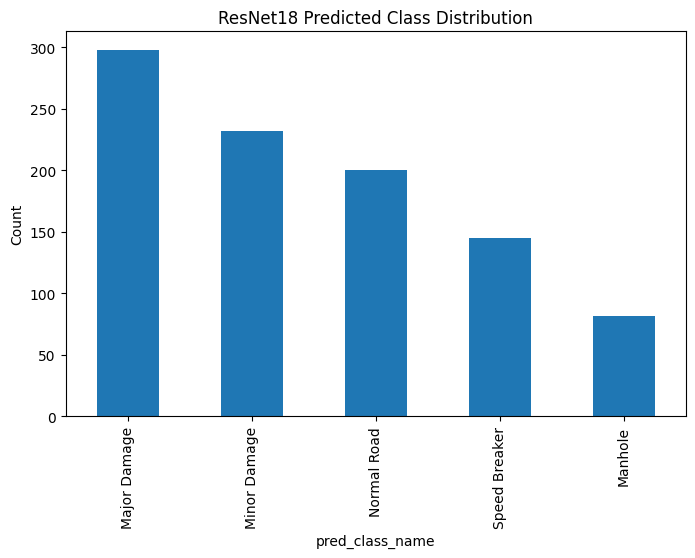

In [36]:
resnet_df["pred_class_name"].value_counts().plot(kind="bar",figsize=(8,5))
plt.ylabel("Count")
plt.title("ResNet18 Predicted Class Distribution")
plt.show()

### EfficientNet_b0 Confidence Score Distribution

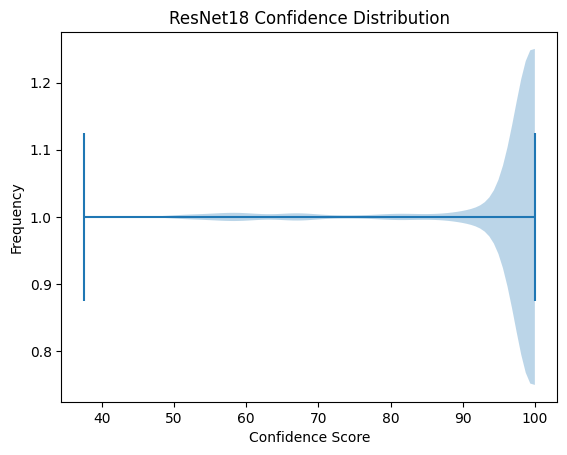

In [37]:
efficientnet_conf_df=efficientnet_df["confidence_score"]
plt.violinplot(vert=False,dataset=efficientnet_conf_df)
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.title("ResNet18 Confidence Distribution")
plt.show()

### Highest Confidence Predictions

In [38]:
efficientnet_df.sort_values("confidence_score",ascending=False).head(5)

,image_path,image_name,true_label,true_class,pred_label,pred_class_name,confidence_score
14,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0189.jpg,0,Major Damage,0,Major Damage,100.0
956,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0024.jpg,4,Speed Breaker,4,Speed Breaker,100.0
16,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0129.jpg,0,Major Damage,0,Major Damage,100.0
19,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0187.jpg,0,Major Damage,0,Major Damage,100.0
20,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0068.jpg,0,Major Damage,0,Major Damage,100.0


### Lowest COnfidence Prediction

In [39]:
efficientnet_df.sort_values("confidence_score").head(5)

,image_path,image_name,true_label,true_class,pred_label,pred_class_name,confidence_score
876,/kaggle/input/datasets/gracyyadav79/road-damag...,test_speed_breaker_0017.jpg,4,Speed Breaker,0,Major Damage,37.50
212,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0030.jpg,0,Major Damage,2,Minor Damage,50.10
5,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0093.jpg,0,Major Damage,2,Minor Damage,50.18
178,/kaggle/input/datasets/gracyyadav79/road-damag...,test_major_damage_0104.jpg,0,Major Damage,2,Minor Damage,50.78
795,/kaggle/input/datasets/gracyyadav79/road-damag...,test_normal_road_0101.jpg,3,Normal Road,3,Normal Road,51.17


# Calculate Evaluation Metrics

In [40]:
def calculate_metrics(df):
    y_true = df["true_label"]
    y_pred = df["pred_label"]
    return {
        "Accuracy": accuracy_score(y_true,y_pred),
        "Precision_Micro": precision_score(y_true,y_pred,average="micro"),
        "Precision_Macro": precision_score(y_true,y_pred,average="macro"),
        "Precision_Weighted": precision_score(y_true,y_pred,average="weighted"),
        "Recall_Micro": recall_score(y_true,y_pred,average="micro"),
        "Recall_Macro": recall_score(y_true,y_pred,average="macro"),
        "Recall_Weighted": recall_score(y_true,y_pred,average="weighted"),
        "F1_Micro": f1_score(y_true,y_pred,average="micro"),
        "F1_Macro": f1_score(y_true,y_pred,average="macro"),
        "F1_Weighted": f1_score(y_true,y_pred,average="weighted")
    }

In [41]:
result_resnet = calculate_metrics(resnet_df)
result_mobilenet = calculate_metrics(mobilenet_df)
result_efficientnet = calculate_metrics(efficientnet_df)

In [42]:
comparison_df = pd.DataFrame([
    {"Model":"ResNet18",**calculate_metrics(resnet_df)},
    {"Model":"MobileNetV3",**calculate_metrics(mobilenet_df)},
    {"Model":"EfficientNet-B0",**calculate_metrics(efficientnet_df)}
])

comparison_df

,Model,Accuracy,Precision_Micro,Precision_Macro,Precision_Weighted,Recall_Micro,Recall_Macro,Recall_Weighted,F1_Micro,F1_Macro,F1_Weighted
0,ResNet18,0.888192,0.888192,0.907845,0.889988,0.888192,0.907631,0.888192,0.888192,0.907527,0.888844
1,MobileNetV3,0.895507,0.895507,0.915719,0.896131,0.895507,0.908724,0.895507,0.895507,0.912022,0.895669
2,EfficientNet-B0,0.890282,0.890282,0.910014,0.890070,0.890282,0.907107,0.890282,0.890282,0.908383,0.890008


## Performance Comparison

## Comfusion Matrix Analysis

In [43]:
def plot_cm(df, title):
    cm = confusion_matrix(df["true_label"], df["pred_label"])
    fig, ax = plt.subplots(figsize=(4, 4))
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Major Damage",
            "Manhole",
            "Minor Damage",
            "Normal Road",
            "Speed Breaker"
        ]
    )
    disp.plot(ax=ax, colorbar=False)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    filename = f"{title.replace(' ', '_')}.png"
    plt.savefig(filename, bbox_inches="tight", dpi=150)
    plt.show()

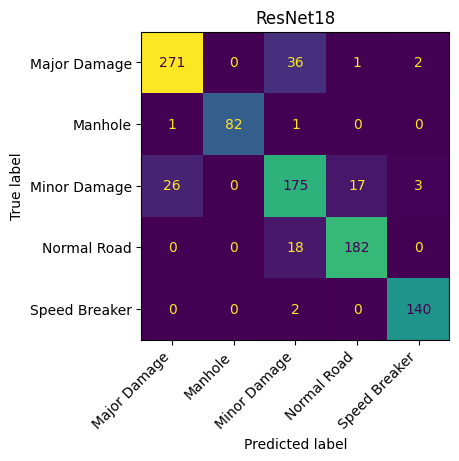

In [44]:
plot_cm(resnet_df,"ResNet18")

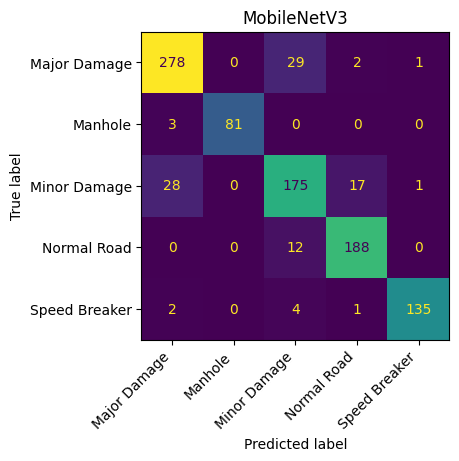

In [45]:
plot_cm(mobilenet_df,"MobileNetV3")

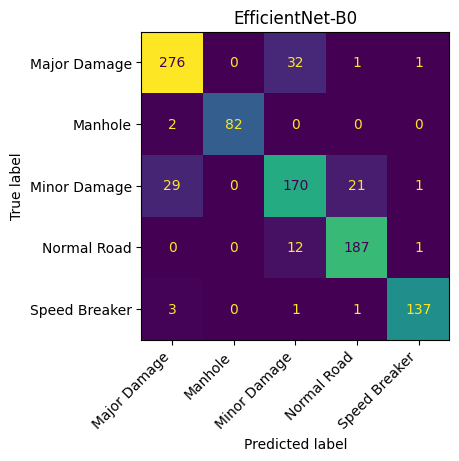

In [46]:
plot_cm(efficientnet_df,"EfficientNet-B0")

In [47]:
comparison_df = pd.DataFrame({
    "Model": [
        "ResNet18",
        "MobileNetV3",
        "EfficientNet-B0"
    ],
    "Accuracy": [
        accuracy_score(resnet_df["true_label"], resnet_df["pred_label"]),
        accuracy_score(mobilenet_df["true_label"], mobilenet_df["pred_label"]),
        accuracy_score(efficientnet_df["true_label"], efficientnet_df["pred_label"])
    ],
    "F1 (Macro)": [
        f1_score(
            resnet_df["true_label"],
            resnet_df["pred_label"],
            average="macro"
        ),

        f1_score(
            mobilenet_df["true_label"],
            mobilenet_df["pred_label"],
            average="macro"
        ),

        f1_score(
            efficientnet_df["true_label"],
            efficientnet_df["pred_label"],
            average="macro"
        )
    ],

    "F1 (Weighted)": [
        f1_score(
            resnet_df["true_label"],
            resnet_df["pred_label"],
            average="weighted"
        ),

        f1_score(
            mobilenet_df["true_label"],
            mobilenet_df["pred_label"],
            average="weighted"
        ),

        f1_score(
            efficientnet_df["true_label"],
            efficientnet_df["pred_label"],
            average="weighted"
        )
    ],

    "Parameters (M)": [
        11.31,
        1.07,
        4.34
    ],

    "Model Size (MB)": [
        43.14,
        4.10,
        16.54
    ]
})
comparison_df = comparison_df.round(4)
comparison_df

,Model,Accuracy,F1 (Macro),F1 (Weighted),Parameters (M),Model Size (MB)
0,ResNet18,0.8882,0.9075,0.8888,11.31,43.14
1,MobileNetV3,0.8955,0.9120,0.8957,1.07,4.10
2,EfficientNet-B0,0.8903,0.9084,0.8900,4.34,16.54


In [50]:
comparison_df.to_csv("model_comparison.csv")

In [49]:
!pwd

/kaggle/working/road-damage-multiclass-classification


# Class Wise metrics

In [51]:
from sklearn.metrics import classification_report

## RESNET18

In [52]:
class_names = [
    "Major Damage",
    "Manhole",
    "Minor Damage",
    "Normal Road",
    "Speed Breaker"
]

resnet_classwise_df = pd.DataFrame(
    classification_report(
        resnet_df["true_label"],
        resnet_df["pred_label"],
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).T

resnet_classwise_df = resnet_classwise_df.round(4)

resnet_classwise_df

,precision,recall,f1-score,support
Major Damage,0.9094,0.8742,0.8914,310.0000
Manhole,1.0000,0.9762,0.9880,84.0000
Minor Damage,0.7543,0.7919,0.7726,221.0000
Normal Road,0.9100,0.9100,0.9100,200.0000
Speed Breaker,0.9655,0.9859,0.9756,142.0000
accuracy,0.8882,0.8882,0.8882,0.8882
macro avg,0.9078,0.9076,0.9075,957.0000
weighted avg,0.8900,0.8882,0.8888,957.0000


## MobileNetV3

In [53]:
mobilenet_classwise_df = pd.DataFrame(
    classification_report(
        mobilenet_df["true_label"],
        mobilenet_df["pred_label"],
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).T

mobilenet_classwise_df = mobilenet_classwise_df.round(4)

mobilenet_classwise_df

,precision,recall,f1-score,support
Major Damage,0.8939,0.8968,0.8953,310.0000
Manhole,1.0000,0.9643,0.9818,84.0000
Minor Damage,0.7955,0.7919,0.7937,221.0000
Normal Road,0.9038,0.9400,0.9216,200.0000
Speed Breaker,0.9854,0.9507,0.9677,142.0000
accuracy,0.8955,0.8955,0.8955,0.8955
macro avg,0.9157,0.9087,0.9120,957.0000
weighted avg,0.8961,0.8955,0.8957,957.0000


## EfficientNet_b0

In [55]:
efficientnet_classwise_df = pd.DataFrame(
    classification_report(
        efficientnet_df["true_label"],
        efficientnet_df["pred_label"],
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).T

efficientnet_classwise_df = efficientnet_classwise_df.round(4)

efficientnet_classwise_df

,precision,recall,f1-score,support
Major Damage,0.8903,0.8903,0.8903,310.0000
Manhole,1.0000,0.9762,0.9880,84.0000
Minor Damage,0.7907,0.7692,0.7798,221.0000
Normal Road,0.8905,0.9350,0.9122,200.0000
Speed Breaker,0.9786,0.9648,0.9716,142.0000
accuracy,0.8903,0.8903,0.8903,0.8903
macro avg,0.9100,0.9071,0.9084,957.0000
weighted avg,0.8901,0.8903,0.8900,957.0000


In [56]:
comparison_classwise_df = pd.DataFrame({
    "ResNet18 F1": resnet_classwise_df.loc[class_names, "f1-score"],
    "MobileNetV3 F1": mobilenet_classwise_df.loc[class_names, "f1-score"],
    "EfficientNet-B0 F1": efficientnet_classwise_df.loc[class_names, "f1-score"]
})

comparison_classwise_df = comparison_classwise_df.round(4)

comparison_classwise_df

,ResNet18 F1,MobileNetV3 F1,EfficientNet-B0 F1
Major Damage,0.8914,0.8953,0.8903
Manhole,0.9880,0.9818,0.9880
Minor Damage,0.7726,0.7937,0.7798
Normal Road,0.9100,0.9216,0.9122
Speed Breaker,0.9756,0.9677,0.9716


In [57]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

In [59]:
class_names = [
    "Major Damage",
    "Manhole",
    "Minor Damage",
    "Normal Road",
    "Speed Breaker"
]

models = {
    "ResNet18": resnet_df,
    "MobileNetV3": mobilenet_df,
    "EfficientNet-B0": efficientnet_df
}

rows = []

for class_idx, class_name in enumerate(class_names):

    support = (
        resnet_df["true_label"] == class_idx
    ).sum()

    row = {
        "Class": class_name,
        "Support": support
    }

    for model_name, df in models.items():

        precision, recall, f1, _ = precision_recall_fscore_support(
            df["true_label"],
            df["pred_label"],
            labels=[class_idx],
            zero_division=0
        )

        row[f"{model_name}_F1"] = f1[0]
        row[f"{model_name}_Precision"] = precision[0]
        row[f"{model_name}_Recall"] = recall[0]

    rows.append(row)

comparison_df = pd.DataFrame(rows)

In [62]:
mean_row = {
    "Class": "Mean",
    "Support": comparison_df["Support"].sum()
}

for column in comparison_df.columns:

    if column not in ["Class", "Support"]:

        mean_row[column] = comparison_df[column].mean()

comparison_df.loc[len(comparison_df)] = mean_row

comparison_df = comparison_df.round(4)

comparison_df

,Class,Support,ResNet18_F1,ResNet18_Precision,ResNet18_Recall,MobileNetV3_F1,MobileNetV3_Precision,MobileNetV3_Recall,EfficientNet-B0_F1,EfficientNet-B0_Precision,EfficientNet-B0_Recall
0,Major Damage,310,0.8914,0.9094,0.8742,0.8953,0.8939,0.8968,0.8903,0.8903,0.8903
1,Manhole,84,0.9880,1.0000,0.9762,0.9818,1.0000,0.9643,0.9880,1.0000,0.9762
2,Minor Damage,221,0.7726,0.7543,0.7919,0.7937,0.7955,0.7919,0.7798,0.7907,0.7692
3,Normal Road,200,0.9100,0.9100,0.9100,0.9216,0.9038,0.9400,0.9122,0.8905,0.9350
4,Speed Breaker,142,0.9756,0.9655,0.9859,0.9677,0.9854,0.9507,0.9716,0.9786,0.9648
5,Mean,957,0.9075,0.9078,0.9076,0.9120,0.9157,0.9087,0.9084,0.9100,0.9071
6,Mean,1914,0.9075,0.9078,0.9076,0.9120,0.9157,0.9087,0.9084,0.9100,0.9071


In [61]:
comparison_df.to_csv("model_class_wise_comparison.csv")

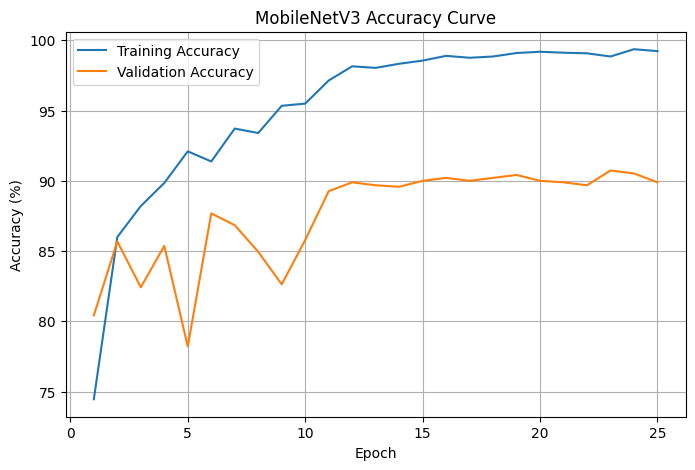

In [64]:
import json
import matplotlib.pyplot as plt

with open(
    "/kaggle/input/datasets/gracyyadav79/model-experiments/final_experiments/mobilenet_v3_small_lr0.001_bs32_20260818_111047/history.json",
    "r"
) as file:

    history = json.load(file)

epochs = history["epoch"]

train_acc = [x * 100 for x in history["train_acc"]]

val_acc = [x * 100 for x in history["val_acc"]]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_acc,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_acc,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("MobileNetV3 Accuracy Curve")

plt.legend()

plt.grid()

plt.savefig("training_curve_mobilnet.png", bbox_inches="tight", dpi=150)

plt.show()